In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.ops import box_iou
from torchvision.tv_tensors import BoundingBoxes
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as v2
from torchvision.models.resnet import resnet50, ResNet50_Weights
import torchmetrics as tm

In [2]:
seed = 42
torch.random.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
root_path = "/home/stefan/ioai-prep/kits/spooky/haunt-me"

batch_size = 64

# Data

In [3]:
class ContrastEnhanceTransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), blur_sigma=0.0):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.blur_sigma = blur_sigma

    def __call__(self, img):
        if isinstance(img, Image.Image):
            img_np = np.array(img)
            if len(img_np.shape) == 3:
                gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            else:
                gray = img_np
        else:
            gray = img

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size
        )
        enhanced = clahe.apply(gray)
        if self.blur_sigma > 0:
            enhanced = cv2.GaussianBlur(enhanced, (3, 3), self.blur_sigma)
        return Image.fromarray(enhanced)


class GrayscaleToRGB:
    def __call__(self, tensor):
        return tensor.repeat(3, 1, 1)  # [1, H, W] -> [3, H, W]


class SpookyDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()

        self.is_train = is_train
        self.dir = f"{root_path}/{'train' if is_train else 'inference'}"
        self.files = os.listdir(self.dir)

        self.base_transforms = v2.Compose([
            ContrastEnhanceTransform(),
        ])

        self.aug_transforms = (v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.3),
            v2.ColorJitter(brightness=0.2, contrast=0.2),
        ]) if is_train else None)

        self.norm_transforms = v2.Compose([
            v2.Resize((224, 224)),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            GrayscaleToRGB(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        if is_train:
            self.df = pd.read_csv("train_data.csv")

    def __getitem__(self, idx):
        file = f"{self.dir}/{self.files[idx]}"
        image_id = self.files[idx][: -len(".jpg")]

        img = Image.open(file).convert("RGB")
        img = self.base_transforms(img)

        if not self.is_train:
            img = self.norm_transforms(img)
            return image_id, img

        row = self.df[self.df["image_id"] == image_id].iloc[0]
        bbox_vals = row.iloc[2:6].tolist()

        if self.aug_transforms:
            img, bboxes = self.aug_transforms(
                img,
                BoundingBoxes([bbox_vals], format="xyxy", canvas_size=(512, 512)),
            )
            bbox_vals = bboxes[0].tolist()

        img = self.norm_transforms(img)
        label = torch.tensor(row.iloc[1], dtype=torch.long)
        bbox = torch.tensor(bbox_vals, dtype=torch.float32) / 512.0

        return {"image": img, "label": label, "bbox": bbox}

    def __len__(self):
        return len(self.files)

In [4]:
train_ds = SpookyDataset(is_train=True)
test_ds = SpookyDataset(is_train=False)

n = len(train_ds)
n_train = int(0.8 * n)
n_val = n - n_train

train_ds, val_ds = random_split(
    train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(seed)
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [5]:
x = next(iter(train_loader))

{k:x[k].shape for k in x.keys()}

{'image': torch.Size([64, 3, 224, 224]),
 'label': torch.Size([64]),
 'bbox': torch.Size([64, 4])}

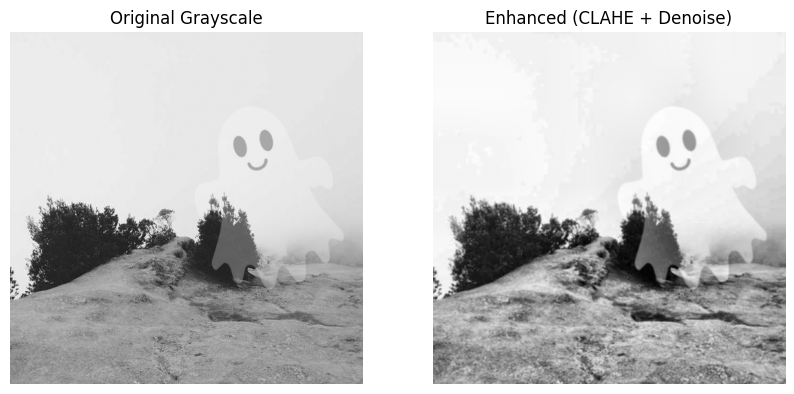

In [6]:
img_bgr = cv2.imread(f"{root_path}/train/img_0005.jpg")
if img_bgr.shape[2] == 4:
    alpha = img_bgr[:, :, 3] / 255.0
    img_bgr = img_bgr[:, :, :3]
    img_bgr = (img_bgr * alpha[:, :, np.newaxis]).astype(np.uint8)

original_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(original_gray)
denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")
axes[1].imshow(denoised, cmap="gray")
axes[1].set_title("Enhanced (CLAHE + Denoise)")
axes[1].axis("off")
plt.show()

# Model

In [7]:
class SpookyNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder.fc = nn.Identity()  # 2048 features

        self.head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(1024, 512),
        )

        self.cls_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(128, 1),
        )

        self.bbox_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3, inplace=True),
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)

        cls = self.cls_head(x)
        box = self.bbox_head(x)

        return cls, box

In [8]:
model = SpookyNet().to(device)

out = model(x["image"].to(device))
[o.shape for o in out]

[torch.Size([64, 1]), torch.Size([64, 4])]

# Training

In [9]:
def evaluate(model, loader):
    acc = tm.Accuracy(task="binary").to(device)
    iou_sum = iou_cnt = 0.0

    model.eval()
    with torch.no_grad():
        for b in loader:
            imgs, labels, bboxes = (
                b["image"].to(device),
                b["label"].to(device),
                b["bbox"].to(device),
            )
            cls_out, box_out = model(imgs)

            prob = torch.sigmoid(cls_out)
            preds = prob.round().long()
            acc(preds.squeeze(), labels)

            # Vectorized IoU for positive samples
            pos_mask = labels.squeeze() == 1
            if pos_mask.any():
                pred_pos = box_out[pos_mask]
                gt_pos = bboxes[pos_mask]

                inter_x1 = torch.max(pred_pos[:, 0], gt_pos[:, 0])
                inter_y1 = torch.max(pred_pos[:, 1], gt_pos[:, 1])
                inter_x2 = torch.min(pred_pos[:, 2], gt_pos[:, 2])
                inter_y2 = torch.min(pred_pos[:, 3], gt_pos[:, 3])

                inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(
                    inter_y2 - inter_y1, min=0
                )
                pred_area = (pred_pos[:, 2] - pred_pos[:, 0]) * (
                    pred_pos[:, 3] - pred_pos[:, 1]
                )
                gt_area = (gt_pos[:, 2] - gt_pos[:, 0]) * (gt_pos[:, 3] - gt_pos[:, 1])

                union_area = pred_area + gt_area - inter_area + 1e-6
                iou_batch = inter_area / union_area

                iou_sum += iou_batch.sum().item()
                iou_cnt += pos_mask.sum().item()

    return {
        "acc": acc.compute().item(),
        "iou": iou_sum / max(iou_cnt, 1),
    }

In [10]:
lr = 2e-3
epochs = 80

weight_cls, weight_box = 1.0, 2.0

In [11]:
def iou_loss(pred, target):
    ious = torch.diag(box_iou(pred, target))
    return (1.0 - ious).mean()

In [12]:
crit_cls = nn.BCEWithLogitsLoss()
crit_box = nn.SmoothL1Loss()
optim = torch.optim.AdamW(model.parameters(), lr=lr)
sched = torch.optim.lr_scheduler.OneCycleLR(
    optim, max_lr=lr, epochs=epochs,
    steps_per_epoch=len(train_loader),
)
scaler = torch.amp.GradScaler(device)

In [13]:
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader):
        imgs = batch["image"].to(device)
        labels = batch["label"].float().unsqueeze(1).to(device)
        boxes_gt = batch["bbox"].to(device)

        with torch.amp.autocast(device):
            pred_cls, pred_box = model(imgs)

            # Classification loss
            loss_cls = crit_cls(pred_cls, labels)

            # Bounding box loss (only for positive samples)
            pos_mask = labels.squeeze() == 1
            loss_box = torch.tensor(0.0, device=device)
            if pos_mask.any():
                loss_box_l1 = crit_box(pred_box[pos_mask], boxes_gt[pos_mask])
                loss_box_iou = iou_loss(pred_box[pos_mask], boxes_gt[pos_mask])
                loss_box = 0.3 * loss_box_l1 + 0.7 * loss_box_iou

            # Combined loss
            loss = weight_cls * loss_cls + weight_box * loss_box

        optim.zero_grad()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optim)
        scaler.update()
        sched.step()

        total_loss += loss.item()

    total_loss = total_loss / len(train_loader)
    metrics = evaluate(model, val_loader)
    print(f"Epoch {epoch}, loss={total_loss:.3f}, metrics={metrics}")

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:06<00:00,  1.46it/s]


Epoch 1, loss=2.128, metrics={'acc': 0.5062500238418579, 'iou': 0.0002341334937676175}


100%|██████████| 10/10 [00:06<00:00,  1.60it/s]


Epoch 2, loss=2.088, metrics={'acc': 0.574999988079071, 'iou': 0.0017686636276441079}


...

Epoch 78, loss=0.392, metrics={'acc': 0.96875, 'iou': 0.7796348937570232}


100%|██████████| 10/10 [00:05<00:00,  1.93it/s]


Epoch 79, loss=0.416, metrics={'acc': 0.956250011920929, 'iou': 0.7609272787015732}


100%|██████████| 10/10 [00:05<00:00,  1.98it/s]


Epoch 80, loss=0.399, metrics={'acc': 0.9750000238418579, 'iou': 0.7994620440757438}


# Submission

In [14]:
submission_rows = []

model.eval()
with torch.no_grad():
    for image_ids, imgs in tqdm(test_loader, desc="Generating submission"):
        imgs = imgs.to(device)
        cls_out, box_out = model(imgs)

        probs = torch.sigmoid(cls_out).squeeze()
        preds = probs.round().long()

        for img_id, pred, prob, box in zip(image_ids, preds, probs, box_out):
            # Classification subtask
            submission_rows.append(
                {"subtaskID": 1, "datapointID": img_id, "answer": str(pred.item())}
            )

            # Localization subtask
            if pred.item() == 1:
                # Convert normalized coordinates to absolute
                box_abs = (box.clamp(0, 1) * 512.0).long()
                box_str = f"[{box_abs[0].item()},{box_abs[1].item()},{box_abs[2].item()},{box_abs[3].item()}]"
            else:
                box_str = "[-1,-1,-1,-1]"

            submission_rows.append(
                {"subtaskID": 2, "datapointID": img_id, "answer": box_str}
            )

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("submission.csv", index=False)
print(f"Submission saved with {len(submission_df)} rows")

Generating submission: 100%|██████████| 4/4 [00:01<00:00,  3.99it/s]

Submission saved with 400 rows
